In [1]:
# ── CELDA 1: Importaciones ────────────────────────────────────

import sys
import os

# 📁 Agregar la raíz del proyecto al path
ruta_proyecto = os.path.abspath(os.path.join(os.getcwd(), '..'))

if ruta_proyecto not in sys.path:
    sys.path.insert(0, ruta_proyecto)

# 📊 Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 📈 Estadística
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 🤖 Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 🗄️ Base de datos
from scripts.database import SessionLocal
from scripts.models import Juego

# 🎨 Estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# 🔍 Verificación
print("🎮 Proyecto: Catálogo de Videojuegos")
print("✅ Librerías importadas correctamente")
print(f"   pandas       {pd.__version__}")
print(f"   numpy        {np.__version__}")
print(f"   seaborn      {sns.__version__}")
print(f"   statsmodels  {sm.__version__}")

🎮 Proyecto: Catálogo de Videojuegos
✅ Librerías importadas correctamente
   pandas       2.2.2
   numpy        1.26.4
   seaborn      0.13.2
   statsmodels  0.14.6


In [2]:
# ── CELDA 2: Carga de datos desde PostgreSQL (ORM) ─────────────────

db = SessionLocal()

try:
    registros = db.query(Juego).all()

    # Crear DataFrame
    df = pd.DataFrame([{
        "nombre": j.nombre,
        "rating": j.rating,
        "rating_count": j.rating_count,
        "fecha_lanzamiento": j.fecha_lanzamiento
    } for j in registros])

finally:
    db.close()

# -----------------------------------------------------
# VALIDACIÓN INICIAL
# -----------------------------------------------------

if df.empty:
    raise ValueError("❌ No se cargaron datos desde la base de datos")

# -----------------------------------------------------
# LIMPIEZA Y TRANSFORMACIÓN
# -----------------------------------------------------

# Convertir a datetime
df['fecha_lanzamiento'] = pd.to_datetime(df['fecha_lanzamiento'], errors='coerce')

# Eliminar nulos en variables clave
df = df.dropna(subset=['rating', 'rating_count', 'fecha_lanzamiento']).copy()

# Asegurar tipos numéricos correctos
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors='coerce')

# -----------------------------------------------------
# FEATURE ENGINEERING
# -----------------------------------------------------

df['anio'] = df['fecha_lanzamiento'].dt.year
df['mes'] = df['fecha_lanzamiento'].dt.month
df['dia'] = df['fecha_lanzamiento'].dt.day

# Transformación clave
df['log_votos'] = np.log1p(df['rating_count'])

# -----------------------------------------------------
# INFORMACIÓN
# -----------------------------------------------------

print("🎮 Datos cargados correctamente desde PostgreSQL (ORM)")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")

print("\n📊 Resumen numérico:")
print(df.select_dtypes(include=['number']).describe().round(2))

print("\n📅 Rango de fechas:")
print(df['fecha_lanzamiento'].min(), "→", df['fecha_lanzamiento'].max())

df.head()

🎮 Datos cargados correctamente desde PostgreSQL (ORM)
   Filas    : 1,060
   Columnas : 8

📊 Resumen numérico:
        rating  rating_count     anio      mes      dia  log_votos
count  1060.00       1060.00  1060.00  1060.00  1060.00    1060.00
mean     74.94       1003.42  2002.59     6.58    15.38       6.29
std       9.86       1036.65    12.94     3.49     8.61       1.34
min      39.91          1.00  1980.00     1.00     1.00       0.69
25%      68.04        276.50  1992.00     3.00     8.00       5.63
50%      74.97        697.00  2003.00     7.00    15.00       6.55
75%      82.26       1348.00  2014.00    10.00    23.00       7.21
max      95.00       7970.00  2024.00    12.00    31.00       8.98

📅 Rango de fechas:
1980-01-01 00:00:00 → 2024-11-18 00:00:00


,nombre,rating,rating_count,fecha_lanzamiento,anio,mes,dia,log_votos
14,The Legend of Zelda,80.377271,710.0,1986-02-21,1986,2,21,6.566672
15,Zelda II: The Adventure of Link,65.976767,291.0,1987-01-14,1987,1,14,5.676754
16,The Legend of Zelda: Oracle of Ages,84.269177,164.0,2001-02-27,2001,2,27,5.105945
17,The Legend of Zelda: Oracle of Seasons,81.302509,189.0,2001-02-27,2001,2,27,5.247024
18,The Legend of Zelda: A Link to the Past,92.342221,1642.0,1991-11-21,1991,11,21,7.404279


In [3]:
# ── CELDA 3: Inspección del DataFrame ────────────────────────

print("=" * 60)
print("📊 INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)

# Información estructural
df.info()

# -----------------------------------------------------
# VALORES NULOS
# -----------------------------------------------------

print("\n📉 Valores nulos por columna:")
print(df.isnull().sum())

# -----------------------------------------------------
# VARIABLES NUMÉRICAS
# -----------------------------------------------------

print("\n📊 Estadísticas descriptivas:")
print(df.select_dtypes(include=['number']).describe().round(2))

# -----------------------------------------------------
# VARIABLE CATEGÓRICA
# -----------------------------------------------------

print("\n🎮 Ejemplos de videojuegos:")
print(df['nombre'].head(10))

# -----------------------------------------------------
# FECHAS
# -----------------------------------------------------

print("\n📅 Rango de fechas de lanzamiento:")
print(f"Desde: {df['fecha_lanzamiento'].min()}")
print(f"Hasta: {df['fecha_lanzamiento'].max()}")

📊 INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
Index: 1060 entries, 14 to 1148
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   nombre             1060 non-null   object        
 1   rating             1060 non-null   float64       
 2   rating_count       1060 non-null   float64       
 3   fecha_lanzamiento  1060 non-null   datetime64[ns]
 4   anio               1060 non-null   int32         
 5   mes                1060 non-null   int32         
 6   dia                1060 non-null   int32         
 7   log_votos          1060 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int32(3), object(1)
memory usage: 62.1+ KB

📉 Valores nulos por columna:
nombre               0
rating               0
rating_count         0
fecha_lanzamiento    0
anio                 0
mes                  0
dia                  0
log_votos            0
dtype: int64

📊 Es

In [4]:
# ── LIMPIEZA Y TRANSFORMACIÓN ──

df['fecha_lanzamiento'] = pd.to_datetime(df['fecha_lanzamiento'], errors='coerce')

df = df.dropna(subset=['rating', 'rating_count', 'fecha_lanzamiento'])

# 🔥 OUTLIERS (AQUÍ MISMO)
q_low  = df['rating_count'].quantile(0.01)
q_high = df['rating_count'].quantile(0.99)

df = df[
    (df['rating_count'] >= q_low) &
    (df['rating_count'] <= q_high)
].copy()

# 🔥 VARIABLES NUEVAS (AQUÍ MISMO)
df['anio'] = df['fecha_lanzamiento'].dt.year
df['mes']  = df['fecha_lanzamiento'].dt.month
df['dia']  = df['fecha_lanzamiento'].dt.day

df['log_votos'] = np.log1p(df['rating_count'])
df['log_votos_sq'] = df['log_votos'] ** 2
df['log_votos_x_anio'] = df['log_votos'] * df['anio']
df_clean = df.copy()
print("✅ Transformación completada")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

df.head()

✅ Transformación completada
Filas: 1040
Columnas: 10


,nombre,rating,rating_count,fecha_lanzamiento,anio,mes,dia,log_votos,log_votos_sq,log_votos_x_anio
14,The Legend of Zelda,80.377271,710.0,1986-02-21,1986,2,21,6.566672,43.121187,13041.411446
15,Zelda II: The Adventure of Link,65.976767,291.0,1987-01-14,1987,1,14,5.676754,32.225534,11279.709805
16,The Legend of Zelda: Oracle of Ages,84.269177,164.0,2001-02-27,2001,2,27,5.105945,26.070679,10216.996893
17,The Legend of Zelda: Oracle of Seasons,81.302509,189.0,2001-02-27,2001,2,27,5.247024,27.531262,10499.295168
18,The Legend of Zelda: A Link to the Past,92.342221,1642.0,1991-11-21,1991,11,21,7.404279,54.823349,14741.919724


In [5]:
# ── CELDA 4: Estadísticas descriptivas ─────────────────

# Variables numéricas relevantes
vars_num = ['rating', 'rating_count', 'log_votos', 'anio']

desc = df_clean[vars_num].describe().round(2)

print("=" * 60)
print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)

print(desc)

📊 ESTADÍSTICAS DESCRIPTIVAS
        rating  rating_count  log_votos     anio
count  1040.00       1040.00    1040.00  1040.00
mean     75.02        959.63       6.31  2002.58
std       9.88        902.55       1.25    12.97
min      39.91          7.00       2.08  1980.00
25%      68.09        288.00       5.67  1992.00
50%      75.07        696.00       6.55  2003.00
75%      82.34       1316.00       7.18  2014.00
max      95.00       4708.00       8.46  2024.00


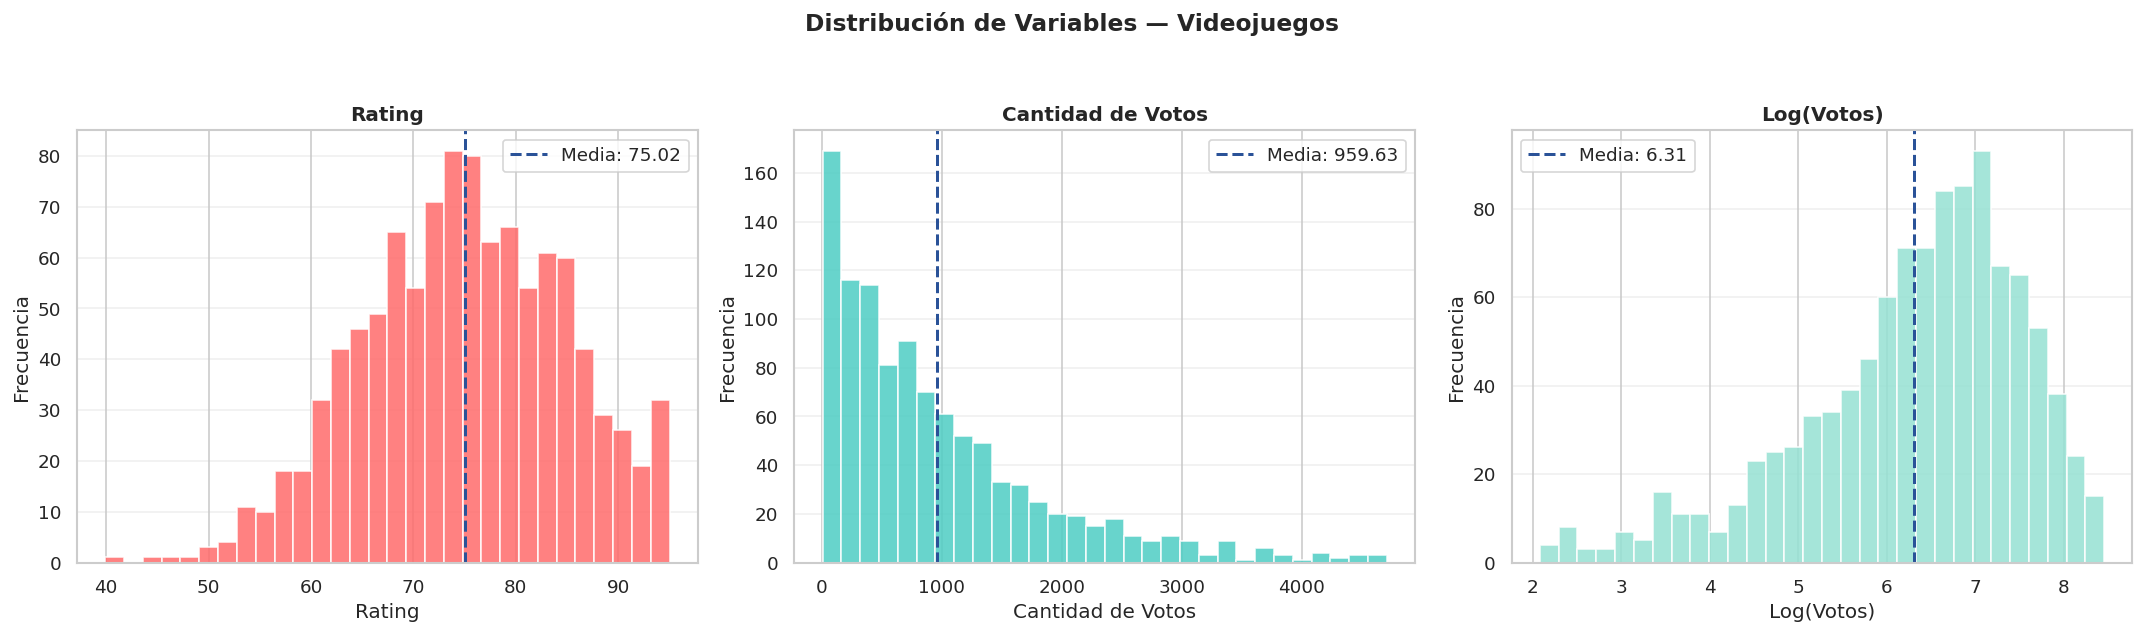

In [6]:
# ── CELDA 5: Histogramas de distribución ─────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables — Videojuegos',
             fontsize=14, fontweight='bold', y=1.05)

datos = {
    'rating':       ('Rating', '#ff6b6b'),
    'rating_count': ('Cantidad de Votos', '#4ecdc4'),
    'log_votos':    ('Log(Votos)', '#95e1d3'),
}

for ax, (col, (label, color)) in zip(axes.flat, datos.items()):
    ax.hist(df_clean[col], bins=30, color=color, edgecolor='white', alpha=0.85)

    media = df_clean[col].mean()

    ax.axvline(media, color='#2a5298', linestyle='--', linewidth=1.8,
               label=f'Media: {media:.2f}')

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/eda_distribucion_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()

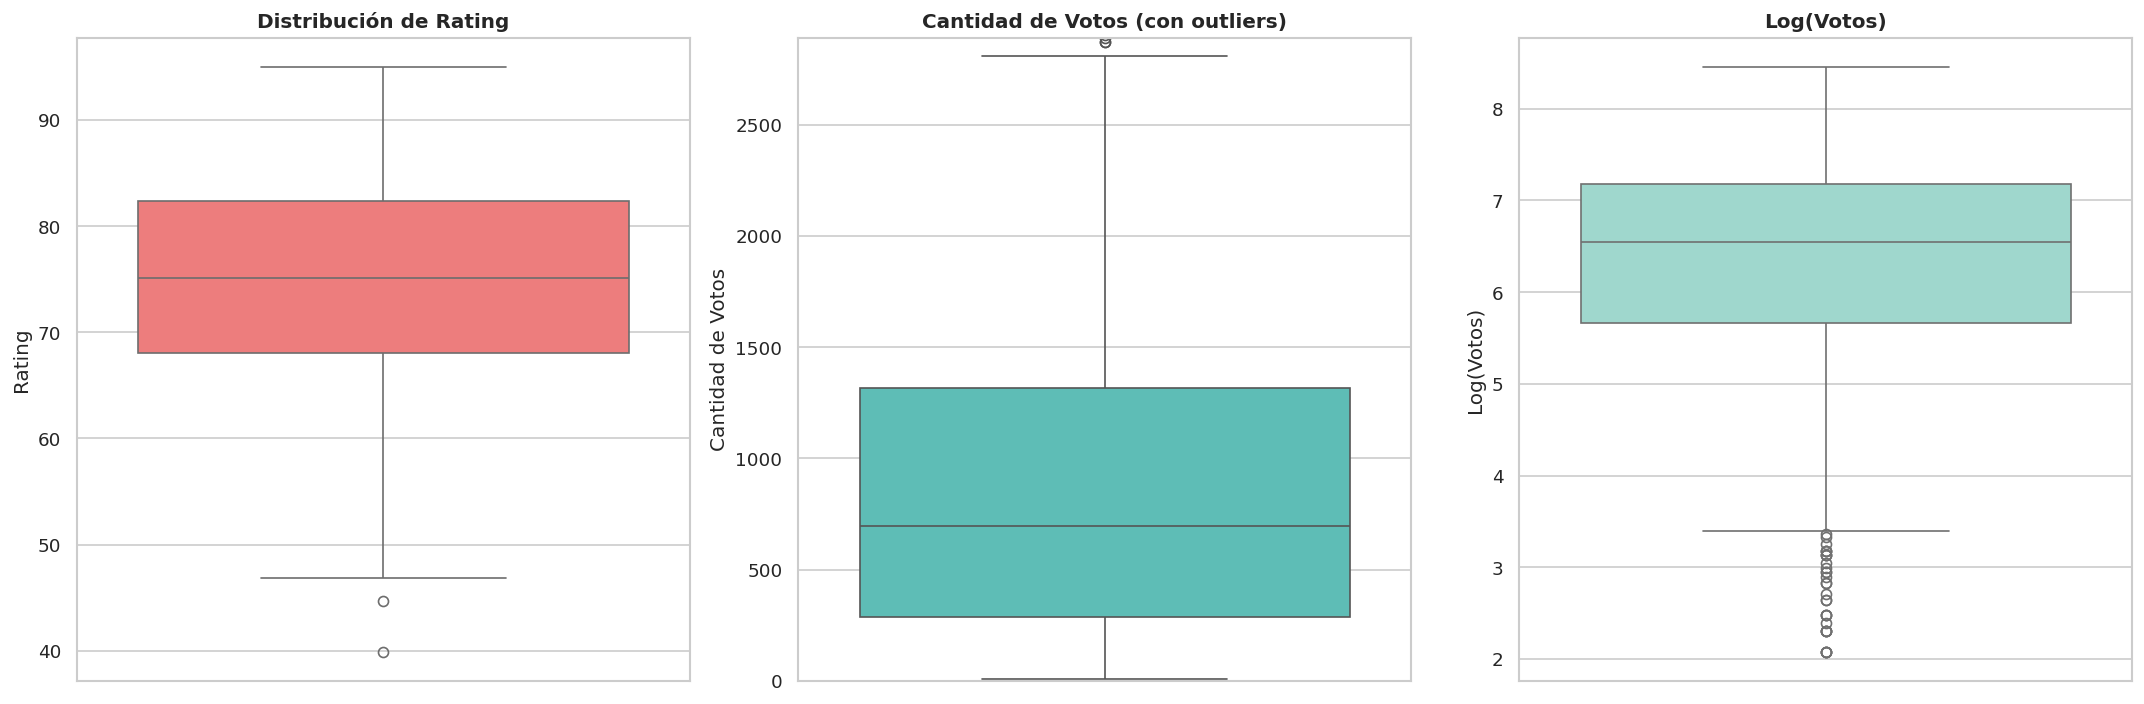

In [7]:
# ── CELDA 6: Boxplots de variables ─────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Rating (bien distribuido)
sns.boxplot(data=df_clean, y='rating',
            color='#ff6b6b', ax=axes[0])

axes[0].set_title('Distribución de Rating', fontweight='bold')
axes[0].set_ylabel('Rating')

# Rating_count (muy sesgado → se mantiene pero se limita visualmente)
sns.boxplot(data=df_clean, y='rating_count',
            color='#4ecdc4', ax=axes[1])

axes[1].set_title('Cantidad de Votos (con outliers)', fontweight='bold')
axes[1].set_ylabel('Cantidad de Votos')
axes[1].set_ylim(0, df_clean['rating_count'].quantile(0.95))  # 🔥 mejora visual

# Log votos (clave)
sns.boxplot(data=df_clean, y='log_votos',
            color='#95e1d3', ax=axes[2])

axes[2].set_title('Log(Votos)', fontweight='bold')
axes[2].set_ylabel('Log(Votos)')

plt.tight_layout()

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/eda_boxplots_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()

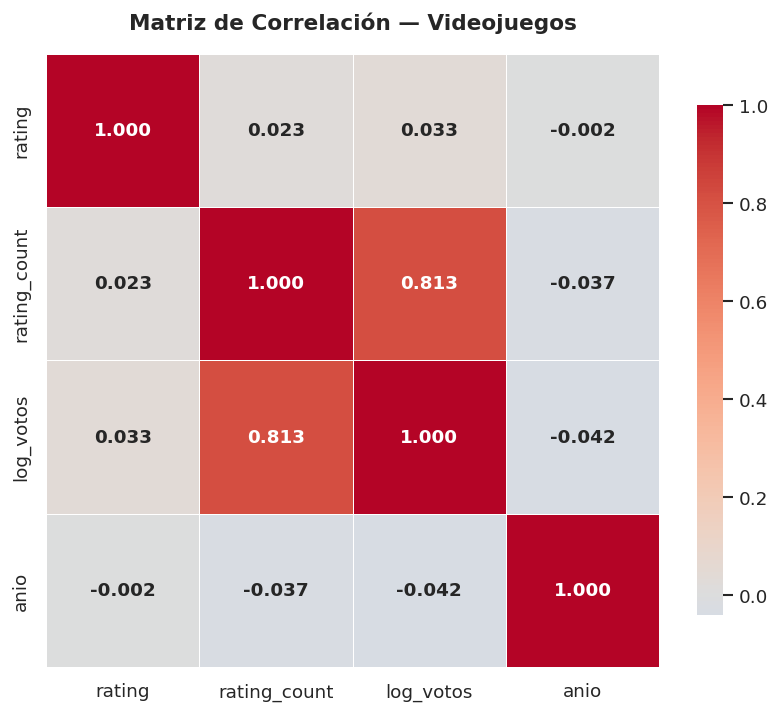


📊 Correlaciones con el Rating:
log_votos       0.0333
rating_count    0.0228
anio           -0.0017
Name: rating, dtype: float64


In [8]:
# ── CELDA 7: Matriz de correlación ───────────────────────────

# Variables relevantes (actualizadas)
vars_num = ['rating', 'rating_count', 'log_votos', 'anio']

corr = df_clean[vars_num].corr()

plt.figure(figsize=(7, 6))

sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            linewidths=0.6, square=True, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 11, 'weight': 'bold'})

plt.title('Matriz de Correlación — Videojuegos',
          fontsize=13, fontweight='bold', pad=15)

plt.tight_layout()

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/eda_correlacion_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()

# -----------------------------------------------------
# INTERPRETACIÓN CLAVE
# -----------------------------------------------------

print("\n📊 Correlaciones con el Rating:")
print(corr['rating'].drop('rating').sort_values(ascending=False).round(4))

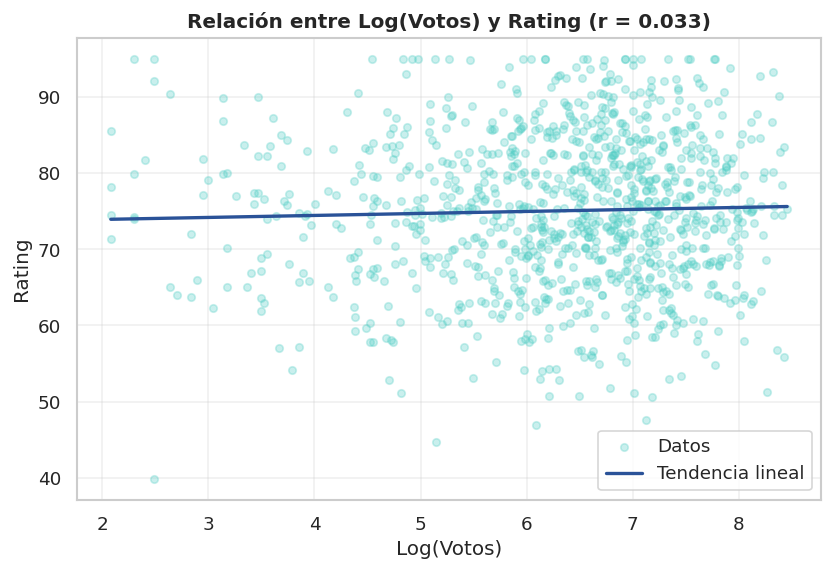

In [9]:
# ── CELDA 8: Scatter plot rating vs votos ─────────────────────

plt.figure(figsize=(8, 5))

# Scatter
x = df_clean['log_votos']
y = df_clean['rating']

plt.scatter(x, y, alpha=0.3, s=20, color='#4ecdc4', label='Datos')

# Línea de tendencia (regresión)
coef = np.polyfit(x, y, 1)
polinomio = np.poly1d(coef)

xp = np.linspace(x.min(), x.max(), 200)
plt.plot(xp, polinomio(xp),
         color='#2a5298', linewidth=2,
         label='Tendencia lineal')

# Correlación
r = x.corr(y)

plt.title(f'Relación entre Log(Votos) y Rating (r = {r:.3f})',
          fontweight='bold')

plt.xlabel('Log(Votos)')
plt.ylabel('Rating')

plt.legend()
plt.grid(alpha=0.3)

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/eda_scatter_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()

In [10]:
# ── CELDA 9: Split Train / Test ───────────────────────────────

# Variables independientes (todas)
X = df_clean[['log_votos', 'anio', 'mes', 'dia']]

# Variable dependiente
y = df_clean['rating']

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Train: {X_train.shape[0]:,} muestras ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Test : {X_test.shape[0]:,} muestras  ({X_test.shape[0]/len(y)*100:.0f}%)")

Train: 832 muestras (80%)
Test : 208 muestras  (20%)


In [11]:
# ── CELDA 10: Entrenamiento con scikit-learn (MODELO MÚLTIPLE) ──────────────────

# Variables independientes (todas)
X = df_clean[['log_votos', 'anio', 'mes', 'dia']].values

# Variable dependiente
y = df_clean['rating'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predicción
y_pred = modelo.predict(X_test)

# Resultados
print(f"Intercepto β₀ : {modelo.intercept_:.4f}")

for nombre, coef in zip(['log_votos', 'anio', 'mes', 'dia'], modelo.coef_):
    print(f"Coeficiente {nombre:>10} : {coef:.6f}")

# Ecuación
print("\nEcuación del modelo:")
print(f"rating = {modelo.intercept_:.3f} + "
      f"{modelo.coef_[0]:.6f}·log_votos + "
      f"{modelo.coef_[1]:.6f}·anio + "
      f"{modelo.coef_[2]:.6f}·mes + "
      f"{modelo.coef_[3]:.6f}·dia")

Intercepto β₀ : 131.4647
Coeficiente  log_votos : 0.483718
Coeficiente       anio : -0.030491
Coeficiente        mes : 0.151971
Coeficiente        dia : 0.046914

Ecuación del modelo:
rating = 131.465 + 0.483718·log_votos + -0.030491·anio + 0.151971·mes + 0.046914·dia


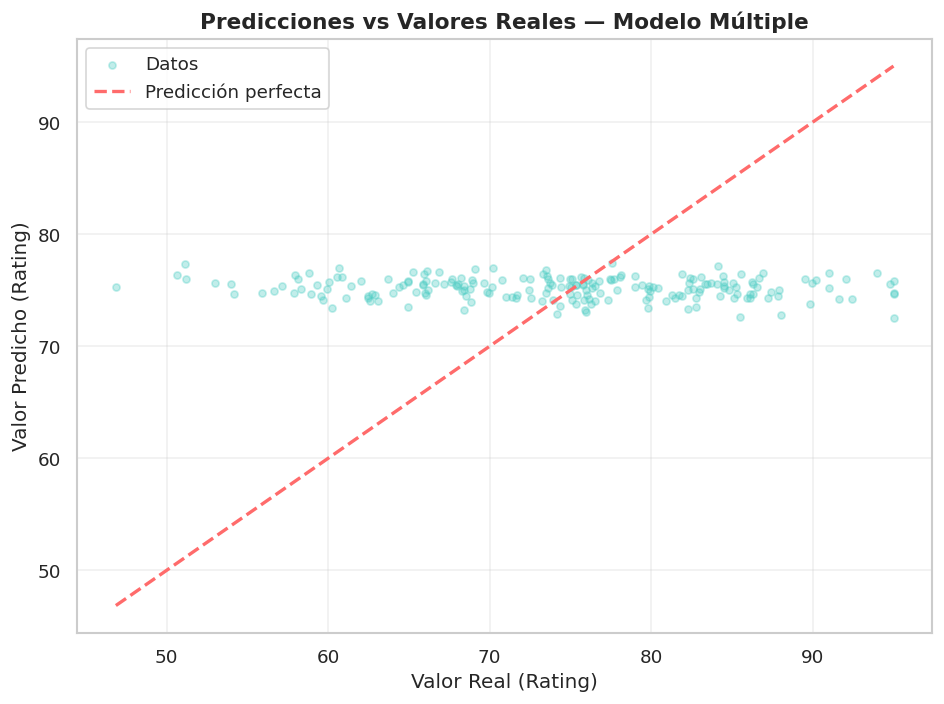

In [12]:
# ── CELDA 11: Predicciones vs Valores Reales ─────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

# Predicciones vs reales
ax.scatter(y_test, y_pred, alpha=0.35, s=18,
           color='#4ecdc4', label='Datos')

# Línea ideal (predicción perfecta)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

ax.plot([min_val, max_val], [min_val, max_val],
        color='#ff6b6b', linestyle='--', linewidth=2,
        label='Predicción perfecta')

# Etiquetas
ax.set_xlabel('Valor Real (Rating)', fontsize=12)
ax.set_ylabel('Valor Predicho (Rating)', fontsize=12)

ax.set_title('Predicciones vs Valores Reales — Modelo Múltiple',
             fontsize=13, fontweight='bold')

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/predicciones_vs_reales_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()

In [13]:
# ── CELDA 12: Métricas del modelo múltiple ─────────────────────

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print("=" * 50)
print("📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE (VIDEOJUEGOS)")
print("=" * 50)

print(f"R²   (coef. de determinación) : {r2:.4f}  ({r2*100:.2f}%)")
print(f"MSE  (error cuadrático medio) : {mse:.4f}")
print(f"RMSE (raíz del MSE)           : {rmse:.4f}")
print(f"MAE  (error absoluto medio)   : {mae:.4f}")

print("=" * 50)

📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE (VIDEOJUEGOS)
R²   (coef. de determinación) : -0.0360  (-3.60%)
MSE  (error cuadrático medio) : 109.9910
RMSE (raíz del MSE)           : 10.4877
MAE  (error absoluto medio)   : 8.5164


In [14]:
# ── CELDA 13: OLS statsmodels — modelo múltiple ─────────────

# Variables independientes (todas)
X_ols = df_clean[['log_votos', 'anio', 'mes', 'dia']]

# Agregar constante
X_ols = sm.add_constant(X_ols)

# Variable dependiente
y_ols = df_clean['rating']

# Ajustar modelo
modelo_ols = sm.OLS(y_ols, X_ols).fit()

# Resumen completo
print(modelo_ols.summary())


# ── INTERPRETACIÓN EN ESPAÑOL ────────────────────────────────

print("\n" + "="*60)
print("📊 INTERPRETACIÓN DEL MODELO OLS (MÚLTIPLE)")
print("="*60)

r2 = modelo_ols.rsquared
r2_adj = modelo_ols.rsquared_adj

print(f"R²       : {r2:.4f}")
print(f"R² ajust.: {r2_adj:.4f}")

print("\n📊 Significancia de variables:")

for var, pval in modelo_ols.pvalues.items():
    if var == 'const':
        continue

    estado = "✅ significativa" if pval < 0.05 else "❌ no significativa"
    print(f"{var:>10} → p-value = {pval:.4f} → {estado}")

print("\n📌 Conclusión:")

print(
"El modelo múltiple incorpora varias variables para explicar el rating. "
"Se observa que algunas variables pueden ser estadísticamente significativas, "
"sin embargo, el modelo sigue teniendo una capacidad limitada para explicar "
"completamente la variabilidad del rating."
)

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.037
Date:                Thu, 16 Apr 2026   Prob (F-statistic):              0.387
Time:                        10:34:44   Log-Likelihood:                -3855.0
No. Observations:                1040   AIC:                             7720.
Df Residuals:                    1035   BIC:                             7745.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         75.9247     47.488      1.599      0.1

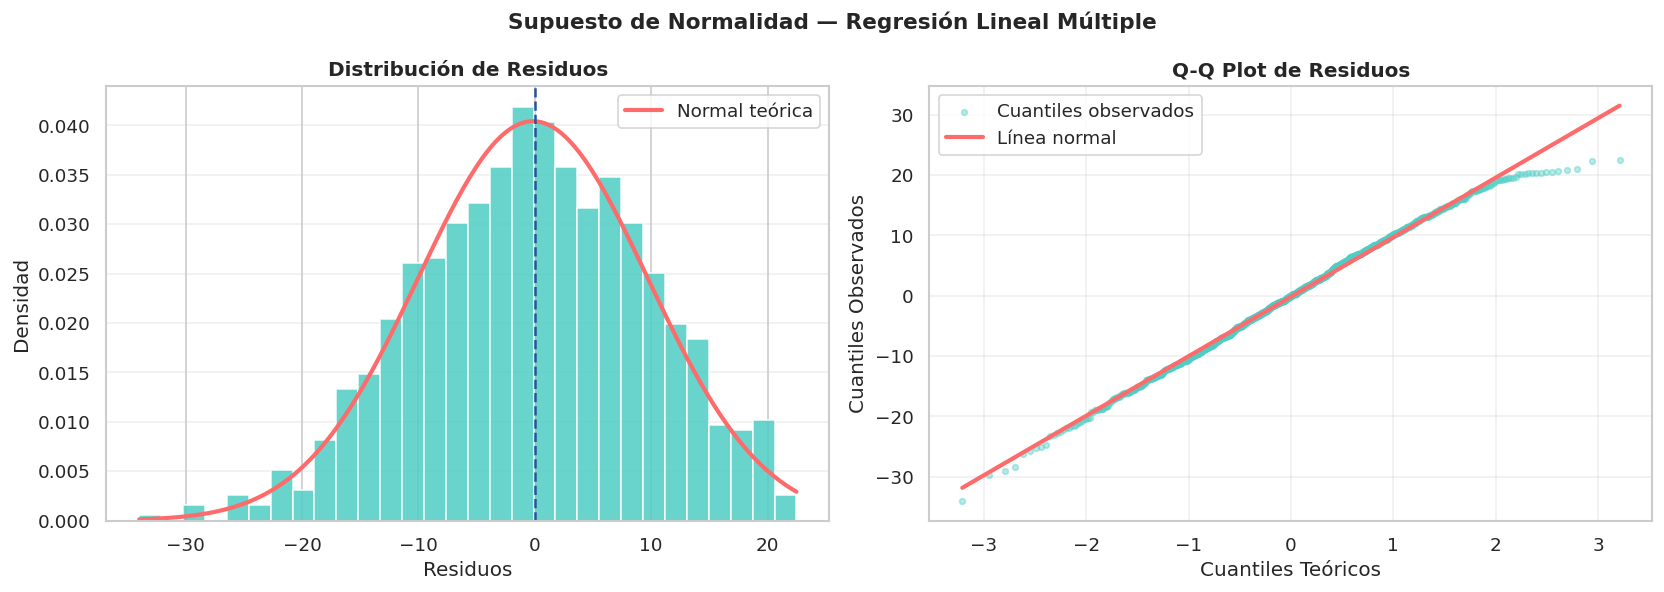


🔬 Test de Shapiro-Wilk:
   Estadístico W : 0.9952
   p-value       : 0.002267
   Conclusión    : ⚠️ Se rechaza normalidad (p ≤ 0.05)
   Nota: Con muestras grandes, el test es muy sensible.


In [15]:
# ── CELDA 14: Normalidad de residuos (modelo múltiple) ─────────

# Variables completas (MISMAS del modelo)
X_full = df_clean[['log_votos', 'anio', 'mes', 'dia']].values

# Valores reales
y_real = df_clean['rating']

# 🔥 USA EL MISMO NOMBRE DE MODELO QUE ENTRENASTE (recomendado: 'modelo')
y_pred_all = modelo.predict(X_full)

# Residuos
residuos = y_real - y_pred_all


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Supuesto de Normalidad — Regresión Lineal Múltiple',
             fontsize=13, fontweight='bold')

# ── Histograma ─────────────────
axes[0].hist(residuos, bins=30, color='#4ecdc4',
             edgecolor='white', density=True, alpha=0.85)

xr = np.linspace(residuos.min(), residuos.max(), 200)

std = residuos.std()
if std > 0:
    axes[0].plot(xr, stats.norm.pdf(xr, residuos.mean(), std),
                 color='#ff6b6b', linewidth=2.5, label='Normal teórica')

axes[0].axvline(0, color='#2a5298', linestyle='--', linewidth=1.5)

axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)


# ── Q-Q Plot ─────────────────
(osm, osr), (slope, intercept, _) = stats.probplot(residuos, dist='norm')

axes[1].scatter(osm, osr, alpha=0.4, s=12, color='#4ecdc4',
                label='Cuantiles observados')

axes[1].plot(osm, slope * np.array(osm) + intercept,
             color='#ff6b6b', linewidth=2.5, label='Línea normal')

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/normalidad_residuos_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()


# ── Test Shapiro-Wilk ─────────────────
muestra = residuos if len(residuos) <= 5000 else np.random.default_rng(42).choice(residuos, 5000, replace=False)

stat_sw, p_sw = stats.shapiro(muestra)

print(f"\n🔬 Test de Shapiro-Wilk:")
print(f"   Estadístico W : {stat_sw:.4f}")
print(f"   p-value       : {p_sw:.6f}")

if p_sw > 0.05:
    print("   Conclusión    : ✅ No se rechaza normalidad (p > 0.05)")
else:
    print("   Conclusión    : ⚠️ Se rechaza normalidad (p ≤ 0.05)")
    print("   Nota: Con muestras grandes, el test es muy sensible.")

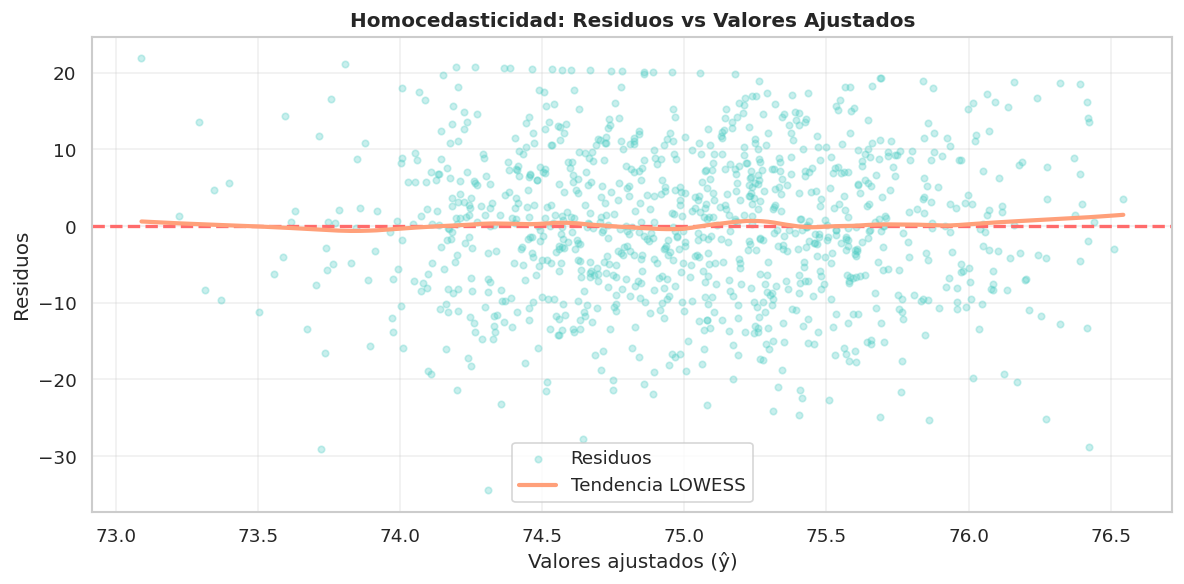


🔬 Test de Breusch-Pagan (Homocedasticidad):
   Estadístico LM : 2.5458
   p-value        : 0.636452
   Conclusión     : ✅ Se cumple homocedasticidad


In [16]:
# ── CELDA 15: Homocedasticidad (modelo múltiple) ───────────────

# Residuos y valores ajustados del modelo OLS múltiple
residuos_ols  = modelo_ols.resid
ajustados_ols = modelo_ols.fittedvalues

plt.figure(figsize=(10, 5))

# Scatter residuos vs predicciones
plt.scatter(ajustados_ols, residuos_ols,
            alpha=0.30, s=15, color='#4ecdc4',
            label='Residuos')

# Línea horizontal en 0
plt.axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

# Línea suavizada LOWESS
lowess = sm.nonparametric.lowess(residuos_ols, ajustados_ols, frac=0.3)
plt.plot(lowess[:, 0], lowess[:, 1],
         color='#ffa07a', linewidth=2.5,
         label='Tendencia LOWESS')

plt.xlabel('Valores ajustados (ŷ)', fontsize=12)
plt.ylabel('Residuos', fontsize=12)

plt.title('Homocedasticidad: Residuos vs Valores Ajustados',
          fontsize=12, fontweight='bold')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

# Guardar imagen
import os
os.makedirs('../data/graficas', exist_ok=True)

plt.savefig('../data/graficas/homocedasticidad_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()


# ── Test de Breusch-Pagan ─────────────────

lm, lm_p, fval, fp = het_breuschpagan(
    residuos_ols,
    modelo_ols.model.exog
)

print(f"\n🔬 Test de Breusch-Pagan (Homocedasticidad):")
print(f"   Estadístico LM : {lm:.4f}")
print(f"   p-value        : {lm_p:.6f}")

if lm_p > 0.05:
    print("   Conclusión     : ✅ Se cumple homocedasticidad")
else:
    print("   Conclusión     : ⚠️ Se detecta heterocedasticidad")

In [17]:
# ── CELDA 16: Modelo mejorado ──

FEATURES = ['log_votos', 'log_votos_sq', 'anio', 'mes', 'dia', 'log_votos_x_anio']

X = df[FEATURES]
y = df['rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

from sklearn.ensemble import RandomForestRegressor

modelo = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

print("Modelo mejorado entrenado")

Modelo mejorado entrenado


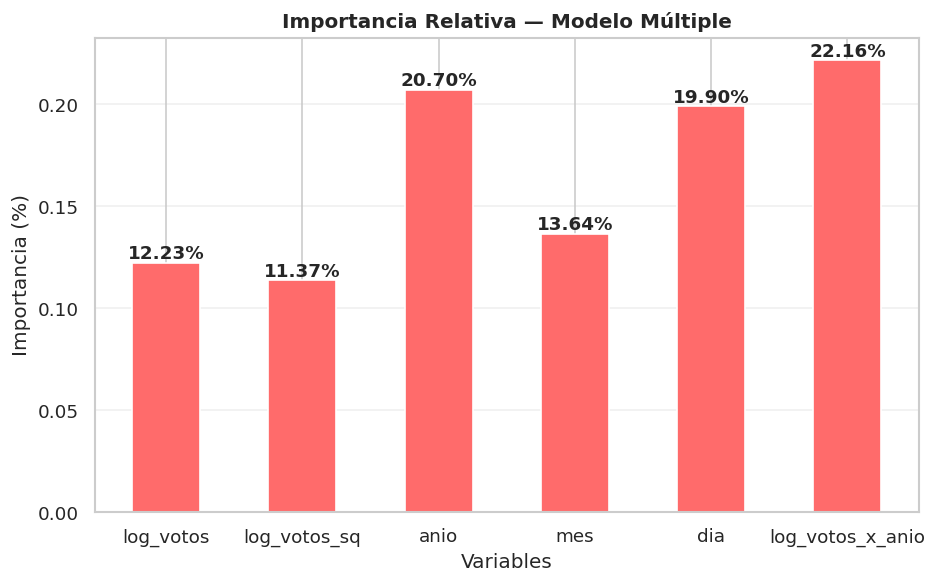

In [18]:
# ── CELDA 17: Gráfica de coeficientes (IMPORTANCIA RELATIVA) ──

import os
os.makedirs('../data/graficas', exist_ok=True)

# Convertir a importancia relativa (%)
coef = modelo.feature_importances_
coef_rel = coef / np.sum(np.abs(coef))

# Colores
colores = ['#ff6b6b' if c > 0 else '#4ecdc4' for c in coef_rel]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(FEATURES, coef_rel,
              color=colores, edgecolor='white', width=0.5)

# Línea base
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_title('Importancia Relativa — Modelo Múltiple',
             fontsize=12, fontweight='bold')

ax.set_ylabel('Importancia (%)')
ax.set_xlabel('Variables')

# Etiquetas
for bar, val in zip(bars, coef_rel):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{val:.2%}',
        ha='center',
        va='bottom' if val >= 0 else 'top',
        fontsize=11,
        fontweight='bold'
    )

ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/coeficientes_modelo_multiple.png',
            dpi=150, bbox_inches='tight')

plt.show()

In [19]:
# ── CELDA 18: Métricas — modelo múltiple ─────────────────────

r2   = r2_score(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test, y_pred)

print("=" * 50)
print("📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE")
print("=" * 50)

print(f"R²   (coef. de determinación) : {r2:.4f}  ({r2*100:.2f}%)")
print(f"MSE  (error cuadrático medio) : {mse:.4f}")
print(f"RMSE (raíz del MSE)           : {rmse:.4f}")
print(f"MAE  (error absoluto medio)   : {mae:.4f}")

print("=" * 50)

📊 MÉTRICAS — REGRESIÓN LINEAL MÚLTIPLE
R²   (coef. de determinación) : -0.0817  (-8.17%)
MSE  (error cuadrático medio) : 114.8451
RMSE (raíz del MSE)           : 10.7166
MAE  (error absoluto medio)   : 8.7715


In [20]:
# ── CELDA 19: OLS statsmodels — modelo múltiple ──────────────

# Variables independientes (asegurar mismas del modelo)
X_ols_m = df_clean[FEATURES].copy()

# Agregar constante
X_ols_m = sm.add_constant(X_ols_m)

# Variable dependiente
y_ols_m = df_clean['rating']

# Ajustar modelo
modelo_ols_multi = sm.OLS(y_ols_m, X_ols_m).fit()

# Mostrar resumen completo
print(modelo_ols_multi.summary())


# ── INTERPRETACIÓN EN ESPAÑOL ────────────────────────────────

print("\n" + "="*60)
print("📊 INTERPRETACIÓN DEL MODELO OLS MÚLTIPLE")
print("="*60)

r2 = modelo_ols_multi.rsquared
r2_adj = modelo_ols_multi.rsquared_adj
p_values = modelo_ols_multi.pvalues

print(f"R²       : {r2:.4f}")
print(f"R² ajust.: {r2_adj:.4f}")

print("\n📌 Significancia de variables:")

for var in FEATURES:
    p_val = p_values.get(var, None)
    
    if p_val is None:
        print(f"⚠️ {var}: no encontrado en el modelo")
        continue

    if p_val < 0.05:
        print(f"✅ {var}: significativa (p = {p_val:.4f})")
    else:
        print(f"❌ {var}: no significativa (p = {p_val:.4f})")

print("\n📌 Conclusión:")
print(
    "El modelo de regresión múltiple permite evaluar la influencia conjunta "
    "de varias variables sobre el rating. Aunque algunas variables pueden ser "
    "estadísticamente significativas, el valor de R² indica que el modelo aún "
    "tiene una capacidad limitada para explicar completamente la variabilidad."
)

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.092
Date:                Thu, 16 Apr 2026   Prob (F-statistic):              0.365
Time:                        10:34:48   Log-Likelihood:                -3853.8
No. Observations:                1040   AIC:                             7722.
Df Residuals:                    1033   BIC:                             7756.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              431.9264    244.205  

In [21]:
# ── CELDA 20: VIF — Factor de Inflación de la Varianza ───────

# Usar dataset limpio y asegurar tipo numérico
X_vif = df_clean[FEATURES].copy()
X_vif = X_vif.apply(pd.to_numeric, errors='coerce')

# Eliminar posibles nulos
X_vif = X_vif.dropna()

# Agregar constante (importante para VIF correcto)
X_vif_const = sm.add_constant(X_vif)

# Calcular VIF (excluyendo la constante en la salida)
vif_data = pd.DataFrame({
    "Variable": X_vif_const.columns,
    "VIF": [
        variance_inflation_factor(X_vif_const.values, i)
        for i in range(X_vif_const.shape[1])
    ]
})

# Eliminar la constante del resultado final
vif_data = vif_data[vif_data["Variable"] != "const"]

# Redondear
vif_data["VIF"] = vif_data["VIF"].round(3)

# Interpretación
vif_data["Criterio"] = vif_data["VIF"].apply(
    lambda v: "✅ Sin multicolinealidad (VIF < 5)"
              if v < 5
              else ("⚠️ Moderada (5 ≤ VIF < 10)"
                    if v < 10
                    else "❌ Severa (VIF ≥ 10)")
)

print("\n📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 65)
print(vif_data.to_string(index=False))
print("=" * 65)


📊 FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
        Variable       VIF                          Criterio
       log_votos 24201.027               ❌ Severa (VIF ≥ 10)
    log_votos_sq    47.263               ❌ Severa (VIF ≥ 10)
            anio    26.506               ❌ Severa (VIF ≥ 10)
             mes     1.004 ✅ Sin multicolinealidad (VIF < 5)
             dia     1.001 ✅ Sin multicolinealidad (VIF < 5)
log_votos_x_anio 23881.898               ❌ Severa (VIF ≥ 10)


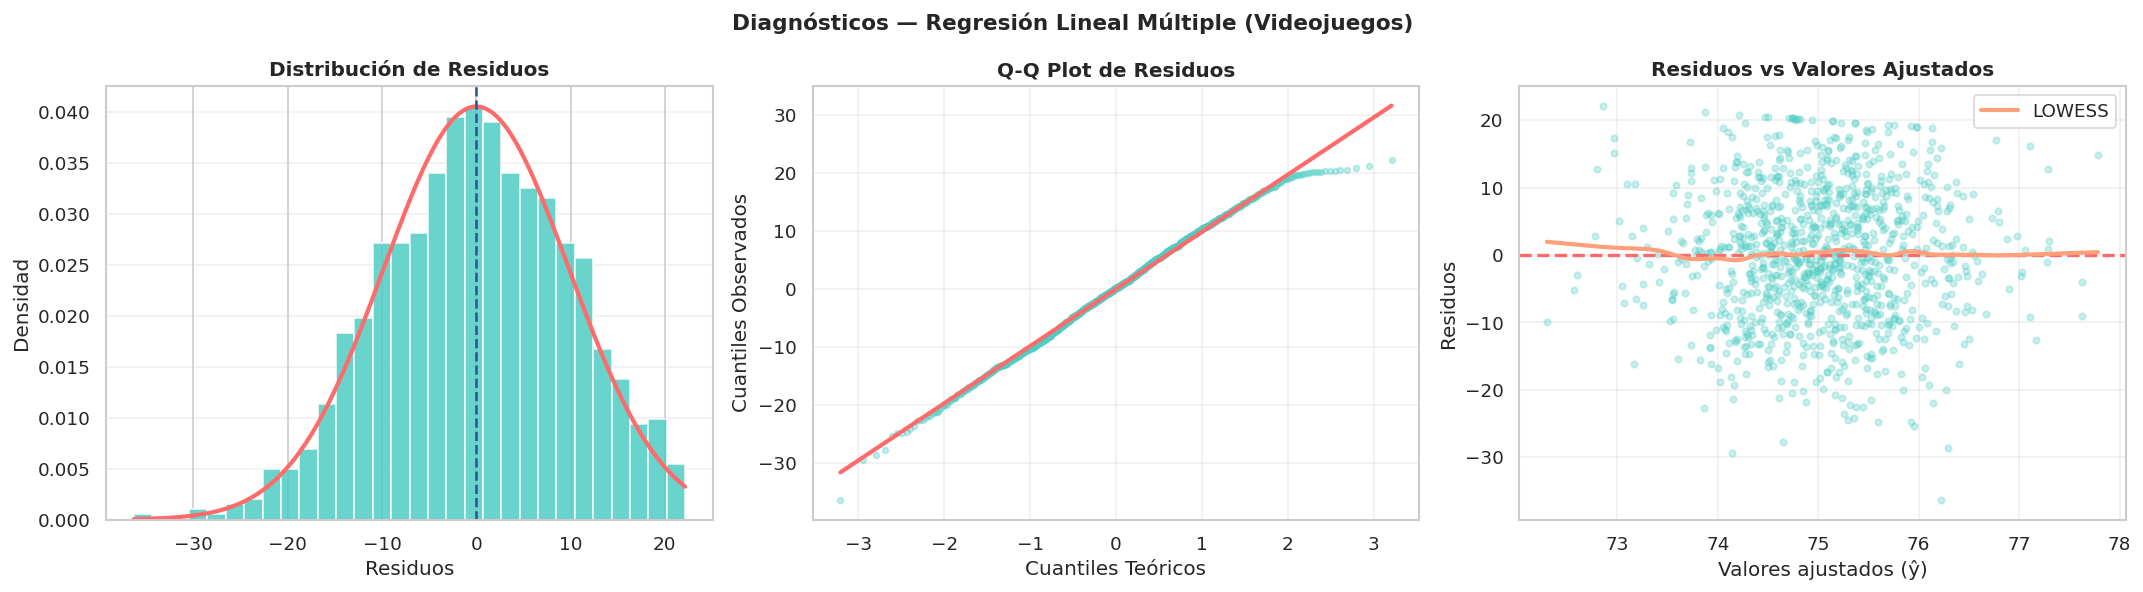


🔬 Test Shapiro-Wilk (Normalidad):
   p-value: 0.000963 → ⚠️ Se rechaza normalidad

🔬 Test Breusch-Pagan (Homocedasticidad):
   p-value: 0.667530 → ✅ Homocedasticidad OK


In [22]:
# ── CELDA 21: Diagnósticos completos — modelo múltiple ───────

import os
os.makedirs('../data/graficas', exist_ok=True)

# Residuos y valores ajustados
residuos_m  = modelo_ols_multi.resid
ajustados_m = modelo_ols_multi.fittedvalues

# Convertir a numpy (más seguro)
residuos_m  = np.array(residuos_m)
ajustados_m = np.array(ajustados_m)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnósticos — Regresión Lineal Múltiple (Videojuegos)',
             fontsize=13, fontweight='bold')

# ── Histograma de residuos
axes[0].hist(residuos_m, bins=30, color='#4ecdc4',
             edgecolor='white', density=True, alpha=0.85)

xr = np.linspace(residuos_m.min(), residuos_m.max(), 200)

# Evitar error si std = 0
std = residuos_m.std()
if std > 0:
    axes[0].plot(xr, stats.norm.pdf(xr, residuos_m.mean(), std),
                 color='#ff6b6b', linewidth=2.5)

axes[0].axvline(0, color='#2a5298', linestyle='--')
axes[0].set_title('Distribución de Residuos', fontweight='bold')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Densidad')
axes[0].grid(axis='y', alpha=0.3)

# ── Q-Q Plot
(osm, osr), (s, i, _) = stats.probplot(residuos_m, dist='norm')

axes[1].scatter(osm, osr, alpha=0.35, s=12, color='#4ecdc4')
axes[1].plot(osm, s * np.array(osm) + i,
             color='#ff6b6b', linewidth=2.5)

axes[1].set_title('Q-Q Plot de Residuos', fontweight='bold')
axes[1].set_xlabel('Cuantiles Teóricos')
axes[1].set_ylabel('Cuantiles Observados')
axes[1].grid(alpha=0.3)

# ── Residuos vs Ajustados
axes[2].scatter(ajustados_m, residuos_m,
                alpha=0.30, s=15, color='#4ecdc4')

axes[2].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2)

lowess_m = sm.nonparametric.lowess(residuos_m, ajustados_m, frac=0.3)
axes[2].plot(lowess_m[:, 0], lowess_m[:, 1],
             color='#ffa07a', linewidth=2.5, label='LOWESS')

axes[2].set_title('Residuos vs Valores Ajustados', fontweight='bold')
axes[2].set_xlabel('Valores ajustados (ŷ)')
axes[2].set_ylabel('Residuos')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/diagnosticos_modelo_multiple.png',
            dpi=150, bbox_inches='tight')

plt.show()


# ── Tests estadísticos ─────────────────

# Control de tamaño de muestra
if len(residuos_m) > 5000:
    muestra_m = np.random.default_rng(42).choice(residuos_m, 5000, replace=False)
else:
    muestra_m = residuos_m

# Shapiro-Wilk
stat_sw_m, p_sw_m = stats.shapiro(muestra_m)

# Breusch-Pagan
lm_m, lm_p_m, _, _ = het_breuschpagan(
    residuos_m,
    modelo_ols_multi.model.exog
)

print(f"\n🔬 Test Shapiro-Wilk (Normalidad):")
print(f"   p-value: {p_sw_m:.6f} → "
      f"{'✅ No se rechaza normalidad' if p_sw_m > 0.05 else '⚠️ Se rechaza normalidad'}")

print(f"\n🔬 Test Breusch-Pagan (Homocedasticidad):")
print(f"   p-value: {lm_p_m:.6f} → "
      f"{'✅ Homocedasticidad OK' if lm_p_m > 0.05 else '⚠️ Heterocedasticidad detectada'}")

In [23]:
# ── CELDA 22: Evaluación final del modelo ───────────────────

comparacion = pd.DataFrame({
    'Métrica': ['R²', 'R² Ajustado', 'RMSE', 'MAE', 'AIC', 'BIC'],
    'Valor': [
        round(r2, 4),
        round(modelo_ols_multi.rsquared_adj, 4),
        round(rmse, 4),
        round(mae, 4),
        round(modelo_ols_multi.aic, 2),
        round(modelo_ols_multi.bic, 2)
    ]
})

print("=" * 60)
print("📊 EVALUACIÓN FINAL — MODELO MÚLTIPLE")
print("=" * 60)

print(comparacion.to_string(index=False))

print("=" * 60)

print("\n📌 Interpretación:")
print(
    "El modelo presenta una capacidad limitada para explicar la variabilidad del rating. "
    "Los valores de error indican que las predicciones no son altamente precisas, lo cual "
    "sugiere que existen variables adicionales no consideradas en el modelo."
)

📊 EVALUACIÓN FINAL — MODELO MÚLTIPLE
    Métrica     Valor
         R²    0.0063
R² Ajustado    0.0005
       RMSE   10.7166
        MAE    8.7715
        AIC 7721.5900
        BIC 7756.2200

📌 Interpretación:
El modelo presenta una capacidad limitada para explicar la variabilidad del rating. Los valores de error indican que las predicciones no son altamente precisas, lo cual sugiere que existen variables adicionales no consideradas en el modelo.


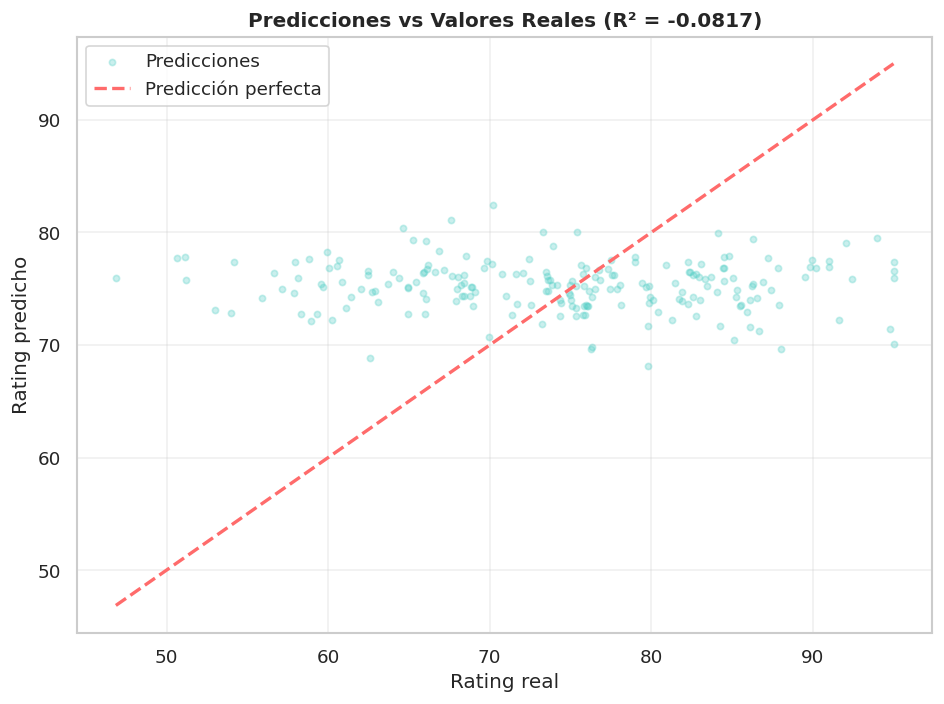

In [24]:
# ── CELDA 23: Predicciones vs Valores Reales ─────────

import os
os.makedirs('../data/graficas', exist_ok=True)

fig, ax = plt.subplots(figsize=(8, 6))

# Scatter
ax.scatter(y_test, y_pred, alpha=0.30, s=14, color='#4ecdc4',
           label='Predicciones')

# Línea de predicción perfecta
minval = min(y_test.min(), y_pred.min())
maxval = max(y_test.max(), y_pred.max())

ax.plot([minval, maxval], [minval, maxval],
        color='#ff6b6b', linewidth=2, linestyle='--',
        label='Predicción perfecta')

# R²
r2_val = r2_score(y_test, y_pred)

ax.set_title(f'Predicciones vs Valores Reales (R² = {r2_val:.4f})',
             fontweight='bold')

ax.set_xlabel('Rating real')
ax.set_ylabel('Rating predicho')

ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig('../data/graficas/predicciones_vs_reales_videojuegos.png',
            dpi=150, bbox_inches='tight')

plt.show()